# Systematic Prediction of Thermal Conductivity (`k`) and Effusivity (`eff`)

This notebook answers the research question:

> Can the post-contact Primary and Secondary sensor responses predict a material's
> thermal conductivity or thermal effusivity?

It deliberately excludes tsfresh and uses two feature families:

1. **Thermal-response features** — interpretable slopes, changes, areas and cross-sensor quantities.
2. **ESN features** — summaries of reservoir dynamics, adapted from the senior's manually coded ESN.

Two evaluation protocols are reported separately:

- **Held-out repetition:** one trial number is excluded across all materials. This tests repeatability for represented materials.
- **Held-out material:** all trials of a material are excluded. This tests generalization to a genuinely unseen material.

The two scores answer different questions and must not be combined.


# 1. Imports and experiment configuration


In [75]:
from pathlib import Path
from itertools import product
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import linalg
from scipy.signal import savgol_filter
from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [76]:
FILE_TITLE = "40C"
RANDOM_STATE = 42

# Post-contact analysis window in seconds.
ANALYSIS_WINDOW = (0.0, 5.0)
EARLY_WINDOW = (0.0, 1.0)
MID_WINDOW = (1.0, 3.0)
LATE_WINDOW = (3.0, 5.0)

# Manual ESN settings.
#ESN_RES_SIZE = 50
#ESN_LEAK_RATE = 0.1
#ESN_INPUT_MAGNITUDE = 1.5
#ESN_SPECTRAL_RADIUS = 1.3
#ESN_WASHOUT = 0

ESN_RES_SIZE = 20
ESN_LEAK_RATE = 0.1
ESN_INPUT_MAGNITUDE = 1.5
ESN_SPECTRAL_RADIUS = 0.7
ESN_WASHOUT = 5

# Regularization is selected inside the outer training data.
RIDGE_ALPHAS = (0.1, 1.0, 10.0, 100.0, 1000.0)

cwd = Path.cwd().resolve()
data_candidates = [
    cwd / "data" / "02_preprocessed" / FILE_TITLE,
    cwd.parent / "data" / "02_preprocessed" / FILE_TITLE,
    cwd.parent.parent / "Warmth Sensor Notebook" / "data" / "02_preprocessed" / FILE_TITLE,
]
DATA_PATH = next((path for path in data_candidates if path.is_dir()), None)
if DATA_PATH is None:
    attempted = "\n".join(str(path) for path in data_candidates)
    raise FileNotFoundError(f"Data directory not found. Tried:\n{attempted}")


# 2. Standard material properties and trial loading

The processed CSV values in `k`, `Mass`, `Volume`, `rho`, and `cp` are deliberately
ignored. After loading the sensor data, the notebook overwrites those fields using
the authoritative table below.

`Mass=1 kg` and `Volume=1 m³` are placeholders and can be updated later.


In [77]:
STANDARD_PROPERTIES = {
    "ps_foam":   {"k": 0.034, "Mass": 1.0, "Volume": 1.0, "rho": 25.0,   "cp": 1400.0},
    "pu_foam":   {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 30.0,   "cp": 1400.0},
    "cork":      {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 240.0,  "cp": 1800.0},
    "wood":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 700.0,  "cp": 1700.0},
    "pdms":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 970.0,  "cp": 1460.0},
    "gypsum":    {"k": 0.170, "Mass": 1.0, "Volume": 1.0, "rho": 800.0,  "cp": 1090.0},
    "cement":    {"k": 0.290, "Mass": 1.0, "Volume": 1.0, "rho": 1440.0, "cp": 750.0},
    "graphite":  {"k": 100.0, "Mass": 1.0, "Volume": 1.0, "rho": 1820.0, "cp": 710.0},
    "bismuth":   {"k": 8.1,   "Mass": 1.0, "Volume": 1.0, "rho": 9780.0, "cp": 130.0},
    "titanium":  {"k": 21.9,  "Mass": 1.0, "Volume": 1.0, "rho": 4506.0, "cp": 523.0},
    "nickel":    {"k": 90.9,  "Mass": 1.0, "Volume": 1.0, "rho": 8908.0, "cp": 461.0},
    "iron":      {"k": 80.4,  "Mass": 1.0, "Volume": 1.0, "rho": 7874.0, "cp": 449.0},
    "aluminum":  {"k": 237.0, "Mass": 1.0, "Volume": 1.0, "rho": 2700.0, "cp": 897.0},
    "copper":    {"k": 401.0, "Mass": 1.0, "Volume": 1.0, "rho": 8960.0, "cp": 385.0},
}

SAMPLE_ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood",
    "pdms": "pdms",
    "gypsum": "gypsum",
    "cement": "cement",
    "graphite": "graphite", "carbon": "graphite",
    "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium",
    "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron",
    "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

standard_table = (
    pd.DataFrame.from_dict(STANDARD_PROPERTIES, orient="index")
    .rename_axis("Material")
    .reset_index()
)
display(standard_table)

required = {"Sample", "Trial", "Time", "Primary", "Secondary"}
frames = []

for path in sorted(DATA_PATH.glob("*.csv")):
    frame = pd.read_csv(path)
    missing = required - set(frame.columns)
    if missing:
        warnings.warn(f"Skipping {path.name}; missing {sorted(missing)}")
        continue
    frames.append(frame)

if not frames:
    raise ValueError("No valid trial files were found.")

DATA = pd.concat(frames, ignore_index=True)
DATA = DATA.replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary", "Secondary"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required)).copy()
DATA["Trial"] = DATA["Trial"].astype(int)

normalized_sample = (
    DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
)
DATA["Sample"] = normalized_sample.map(SAMPLE_ALIASES)
unknown_mask = DATA["Sample"].isna()
if unknown_mask.any():
    unknown = sorted(normalized_sample[unknown_mask].unique())
    raise KeyError(f"No standard-property mapping for samples: {unknown}")

# Overwrite processed-file properties unconditionally.
for property_name in ("k", "Mass", "Volume", "rho", "cp"):
    DATA[property_name] = DATA["Sample"].map(
        lambda sample: STANDARD_PROPERTIES[sample][property_name]
    )

DATA["trial_id"] = (
    DATA["Sample"].astype(str) + "_trial_" + DATA["Trial"].astype(str)
)
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA = DATA.sort_values(["trial_id", "Time"]).reset_index(drop=True)

# Literature k should be stable by material. Density may vary across measured
# specimens/trials, so the derived eff target is allowed to vary by trial.
k_counts = DATA.groupby("Sample")["k"].nunique()
if (k_counts != 1).any():
    raise ValueError(
        f"k is not constant within: {k_counts[k_counts != 1].index.tolist()}"
    )

summary = (
    DATA.groupby(["trial_id", "Sample", "Trial"], as_index=False)
    .agg(
        n_timesteps=("Time", "size"),
        k=("k", "first"),
        eff=("eff", "first"),
    )
)
print(f"Rows: {len(DATA):,}")
print(f"Trials: {DATA['trial_id'].nunique()}")
print(f"Independent materials: {DATA['Sample'].nunique()}")
display(summary.head())


,Material,k,Mass,Volume,rho,cp
0,ps_foam,0.034,1.0,1.0,25.0,1400.0
1,pu_foam,0.043,1.0,1.0,30.0,1400.0
2,cork,0.043,1.0,1.0,240.0,1800.0
3,wood,0.150,1.0,1.0,700.0,1700.0
4,pdms,0.150,1.0,1.0,970.0,1460.0
5,gypsum,0.170,1.0,1.0,800.0,1090.0
6,cement,0.290,1.0,1.0,1440.0,750.0
7,graphite,100.000,1.0,1.0,1820.0,710.0
8,bismuth,8.100,1.0,1.0,9780.0,130.0
9,titanium,21.900,1.0,1.0,4506.0,523.0


Rows: 19,263
Trials: 84
Independent materials: 14


,trial_id,Sample,Trial,n_timesteps,k,eff
0,aluminum_trial_1,aluminum,1,205,237.0,23958.094665
1,aluminum_trial_2,aluminum,2,209,237.0,23958.094665
2,aluminum_trial_3,aluminum,3,221,237.0,23958.094665
3,aluminum_trial_4,aluminum,4,224,237.0,23958.094665
4,aluminum_trial_5,aluminum,5,227,237.0,23958.094665


# 3. Detect contact and align every trial

The elbow is used only to establish a common time origin. Prediction uses the fixed
0–5 second response after contact. Trials are never aligned using `k` or `eff`.


In [78]:
def find_contact_time(
    trial,
    smooth_window=15,
    polyorder=2,
    threshold_frac=0.30,
    skip_samples=5,
):
    clean = (
        trial[["Time", "Primary"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
        .sort_values("Time")
        .drop_duplicates("Time")
        .reset_index(drop=True)
    )
    time = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time) <= 0):
        raise ValueError("Insufficient or invalid time samples.")

    work_time = time[skip_samples:]
    work_signal = signal[skip_samples:]
    window = min(int(smooth_window), len(work_signal))
    if window % 2 == 0:
        window -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    if window < minimum:
        raise ValueError("Sequence is too short for smoothing.")

    smooth = savgol_filter(work_signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, work_time)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(work_time[elbow])


In [79]:
aligned_trials = {}
alignment_rows = []

for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact_time = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue

    trial["time_from_contact"] = trial["Time"] - contact_time
    start, end = ANALYSIS_WINDOW
    trial = trial[
        trial["time_from_contact"].between(start, end, inclusive="both")
    ].copy()
    if len(trial) < 10:
        warnings.warn(f"Skipping {trial_id}: too few post-contact samples")
        continue
    aligned_trials[trial_id] = trial.reset_index(drop=True)
    alignment_rows.append({
        "trial_id": trial_id,
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "contact_time": contact_time,
        "n_analysis_samples": len(trial),
    })

ALIGNMENT = pd.DataFrame(alignment_rows)
print(f"Aligned trials retained: {len(aligned_trials)}")
display(ALIGNMENT.head())


Aligned trials retained: 84


,trial_id,Sample,Trial,contact_time,n_analysis_samples
0,aluminum_trial_1,aluminum,1,8.60066,50
1,aluminum_trial_2,aluminum,2,9.20070,51
2,aluminum_trial_3,aluminum,3,10.50070,51
3,aluminum_trial_4,aluminum,4,10.50070,50
4,aluminum_trial_5,aluminum,5,10.40066,50


## Check several alignments visually


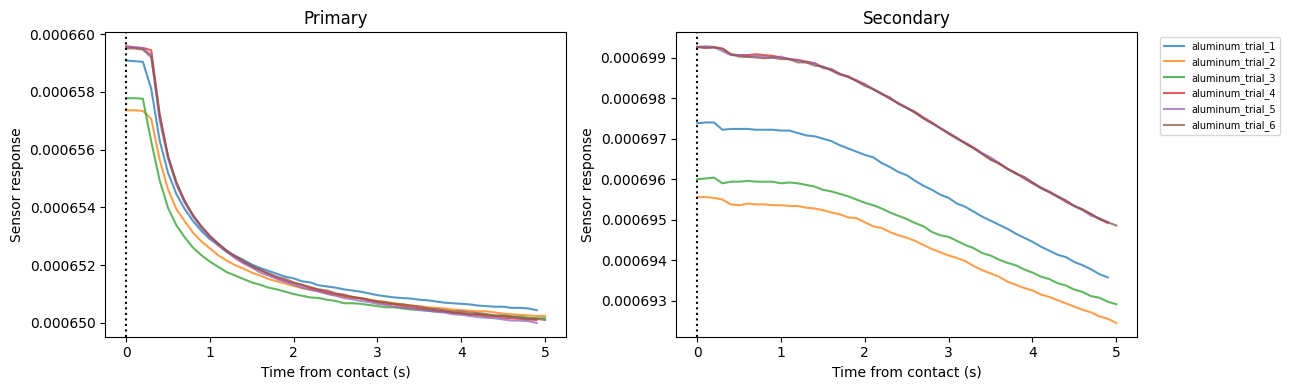

In [80]:
def plot_aligned_trials(material=None, maximum_trials=6):
    selected = list(aligned_trials.values())
    if material is not None:
        selected = [x for x in selected if x["Sample"].iloc[0] == material]
    selected = selected[:maximum_trials]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
    for trial in selected:
        label = trial["trial_id"].iloc[0]
        axes[0].plot(trial["time_from_contact"], trial["Primary"], alpha=0.75, label=label)
        axes[1].plot(trial["time_from_contact"], trial["Secondary"], alpha=0.75, label=label)
    for ax, title in zip(axes, ["Primary", "Secondary"]):
        ax.axvline(0, color="black", linestyle=":")
        ax.set(xlabel="Time from contact (s)", ylabel="Sensor response", title=title)
    axes[1].legend(fontsize=7, bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_aligned_trials(material=ALIGNMENT["Sample"].iloc[0])


# 4. Interpretable thermal-response features


In [81]:
def _smooth(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0:
        selected -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    return (
        savgol_filter(values, selected, polyorder, mode="interp")
        if selected >= minimum else values.copy()
    )


def _slope(time, values, window):
    mask = (time >= window[0]) & (time <= window[1])
    if mask.sum() < 3:
        return np.nan
    return float(np.polyfit(time[mask], values[mask], 1)[0])


def extract_thermal_features(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    secondary = _smooth(trial["Secondary"].to_numpy(float))
    difference = primary - secondary
    result = {}

    for name, signal in {
        "primary": primary,
        "secondary": secondary,
        "difference": difference,
    }.items():
        change = signal - signal[0]
        rate = np.gradient(signal, time)
        result[f"{name}_final_change"] = float(change[-1])
        result[f"{name}_max_abs_change"] = float(np.max(np.abs(change)))
        result[f"{name}_response_auc"] = float(np.trapezoid(np.abs(change), time))
        result[f"{name}_early_slope"] = _slope(time, signal, EARLY_WINDOW)
        result[f"{name}_mid_slope"] = _slope(time, signal, MID_WINDOW)
        result[f"{name}_late_slope"] = _slope(time, signal, LATE_WINDOW)
        result[f"{name}_max_abs_rate"] = float(np.max(np.abs(rate)))
        result[f"{name}_rate_auc"] = float(np.trapezoid(np.abs(rate), time))

    # Dimensionless/cross-sensor summaries.
    primary_auc = result["primary_response_auc"]
    result["secondary_primary_auc_ratio"] = (
        result["secondary_response_auc"] / primary_auc
        if not np.isclose(primary_auc, 0) else np.nan
    )
    result["initial_sensor_difference"] = float(difference[0])
    result["final_sensor_difference"] = float(difference[-1])
    return result


thermal_rows = []
for trial_id, trial in aligned_trials.items():
    features = extract_thermal_features(trial)
    features.update({
        "trial_id": trial_id,
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "k": float(trial["k"].iloc[0]),
        "eff": float(trial["eff"].iloc[0]),
    })
    thermal_rows.append(features)

THERMAL_FEATURES = pd.DataFrame(thermal_rows)
print(f"Thermal features: {len(THERMAL_FEATURES.columns) - 5}")
display(THERMAL_FEATURES.head())


Thermal features: 27


,primary_final_change,primary_max_abs_change,primary_response_auc,primary_early_slope,primary_mid_slope,primary_late_slope,primary_max_abs_rate,primary_rate_auc,secondary_final_change,secondary_max_abs_change,...,difference_max_abs_rate,difference_rate_auc,secondary_primary_auc_ratio,initial_sensor_difference,final_sensor_difference,trial_id,Sample,Trial,k,eff
0,-0.000009,0.000009,0.000038,-0.000007,-8.655030e-07,-2.613835e-07,0.000009,0.000009,-0.000004,0.000004,...,0.000009,0.000010,0.194314,-0.000037,-0.000043,aluminum_trial_1,aluminum,1,237.0,23958.094665
1,-0.000008,0.000008,0.000031,-0.000006,-7.876300e-07,-2.509027e-07,0.000007,0.000008,-0.000003,0.000003,...,0.000007,0.000007,0.199663,-0.000038,-0.000042,aluminum_trial_2,aluminum,2,237.0,23958.094665
2,-0.000008,0.000008,0.000035,-0.000007,-6.910519e-07,-2.115238e-07,0.000010,0.000008,-0.000003,0.000003,...,0.000010,0.000009,0.168984,-0.000037,-0.000043,aluminum_trial_3,aluminum,3,237.0,23958.094665
3,-0.000010,0.000010,0.000041,-0.000008,-9.771796e-07,-3.180339e-07,0.000010,0.000010,-0.000004,0.000004,...,0.000010,0.000010,0.206842,-0.000039,-0.000045,aluminum_trial_4,aluminum,4,237.0,23958.094665
4,-0.000010,0.000010,0.000041,-0.000008,-1.092586e-06,-3.364544e-07,0.000010,0.000010,-0.000004,0.000004,...,0.000010,0.000010,0.209094,-0.000039,-0.000045,aluminum_trial_5,aluminum,5,237.0,23958.094665


# 5. Manual ESN reservoir and trajectory features

The reservoir equation comes from the senior's code, but the logistic `TC` readout is
removed. Instead, each trial's post-contact reservoir trajectory is summarized into
one feature vector for regression.

Input scaling is fitted inside each outer training fold. Therefore ESN features must
also be generated inside each fold.


In [82]:
class ManualReservoir:
    def __init__(
        self,
        res_size=30,
        leak_rate=0.9,
        input_magnitude=1.5,
        spectral_radius=1.3,
        washout=5,
        random_state=42,
    ):
        self.res_size = int(res_size)
        self.leak_rate = float(leak_rate)
        self.input_magnitude = float(input_magnitude)
        self.spectral_radius = float(spectral_radius)
        self.washout = int(washout)
        rng = np.random.default_rng(random_state)
        self.Win = (rng.random((self.res_size, 1 + 5)) - 0.5) * self.input_magnitude
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        if not np.isfinite(radius) or np.isclose(radius, 0):
            raise ValueError("Invalid reservoir spectral radius.")
        self.W = (W / radius.real) * self.spectral_radius

    def run(self, sequence):
        sequence = np.asarray(sequence, float)
        if sequence.ndim != 2 or sequence.shape[1] != 5:
            raise ValueError("Expected sequence with five input channels.")
        if len(sequence) <= self.washout:
            raise ValueError("Sequence is shorter than the ESN washout.")
        x = np.zeros((self.res_size, 1))
        states = []
        for row in sequence:
            u = row.reshape(-1, 1)
            x = (
                (1 - self.leak_rate) * x
                + self.leak_rate * np.tanh(
                    self.Win @ np.vstack((1.0, u)) + self.W @ x
                )
            )
            states.append(x[:, 0].copy())
        return np.asarray(states)[self.washout:]


def raw_esn_input(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    secondary = _smooth(trial["Secondary"].to_numpy(float))
    difference = primary - secondary
    primary_rate = np.gradient(primary, time)
    secondary_rate = np.gradient(secondary, time)
    return np.column_stack([
        primary, secondary, difference, primary_rate, secondary_rate
    ])


def summarize_states(states):
    result = {}
    summaries = {
        "mean": np.mean(states, axis=0),
        "std": np.std(states, axis=0),
        "final": states[-1],
    }
    for summary_name, values in summaries.items():
        for unit, value in enumerate(values):
            result[f"esn_{summary_name}_{unit}"] = float(value)
    return result


# 6. Visualize ESN state evolution

This section shows how the reservoir responds through the 0–5 second post-contact
window. The visualization uses the same reservoir hyperparameters as regression.

The scaler below is fitted across all trials **only for descriptive visualization**.
It is not reused by cross-validation; evaluation continues to fit scaling exclusively
inside each outer training fold.


In [83]:
def compute_visualization_states(trial_id):
    if trial_id not in aligned_trials:
        raise KeyError(trial_id)

    # Descriptive scaler only—never passed into the evaluation engine.
    visualization_scaler = StandardScaler().fit(np.vstack([
        raw_esn_input(trial) for trial in aligned_trials.values()
    ]))
    reservoir = ManualReservoir(
        res_size=ESN_RES_SIZE,
        leak_rate=ESN_LEAK_RATE,
        input_magnitude=ESN_INPUT_MAGNITUDE,
        spectral_radius=ESN_SPECTRAL_RADIUS,
        washout=ESN_WASHOUT,
        random_state=RANDOM_STATE,
    )
    trial = aligned_trials[trial_id]
    scaled_sequence = visualization_scaler.transform(raw_esn_input(trial))
    states = reservoir.run(scaled_sequence)
    time = trial["time_from_contact"].to_numpy(float)[ESN_WASHOUT:]
    return trial, time, scaled_sequence[ESN_WASHOUT:], states


SELECTED_TRIAL_ID = ALIGNMENT["trial_id"].iloc[0]
selected_trial, state_time, selected_inputs, selected_states = (
    compute_visualization_states(SELECTED_TRIAL_ID)
)

print("Selected trial:", SELECTED_TRIAL_ID)
print("Reservoir-state matrix:", selected_states.shape)


Selected trial: aluminum_trial_1
Reservoir-state matrix: (45, 20)


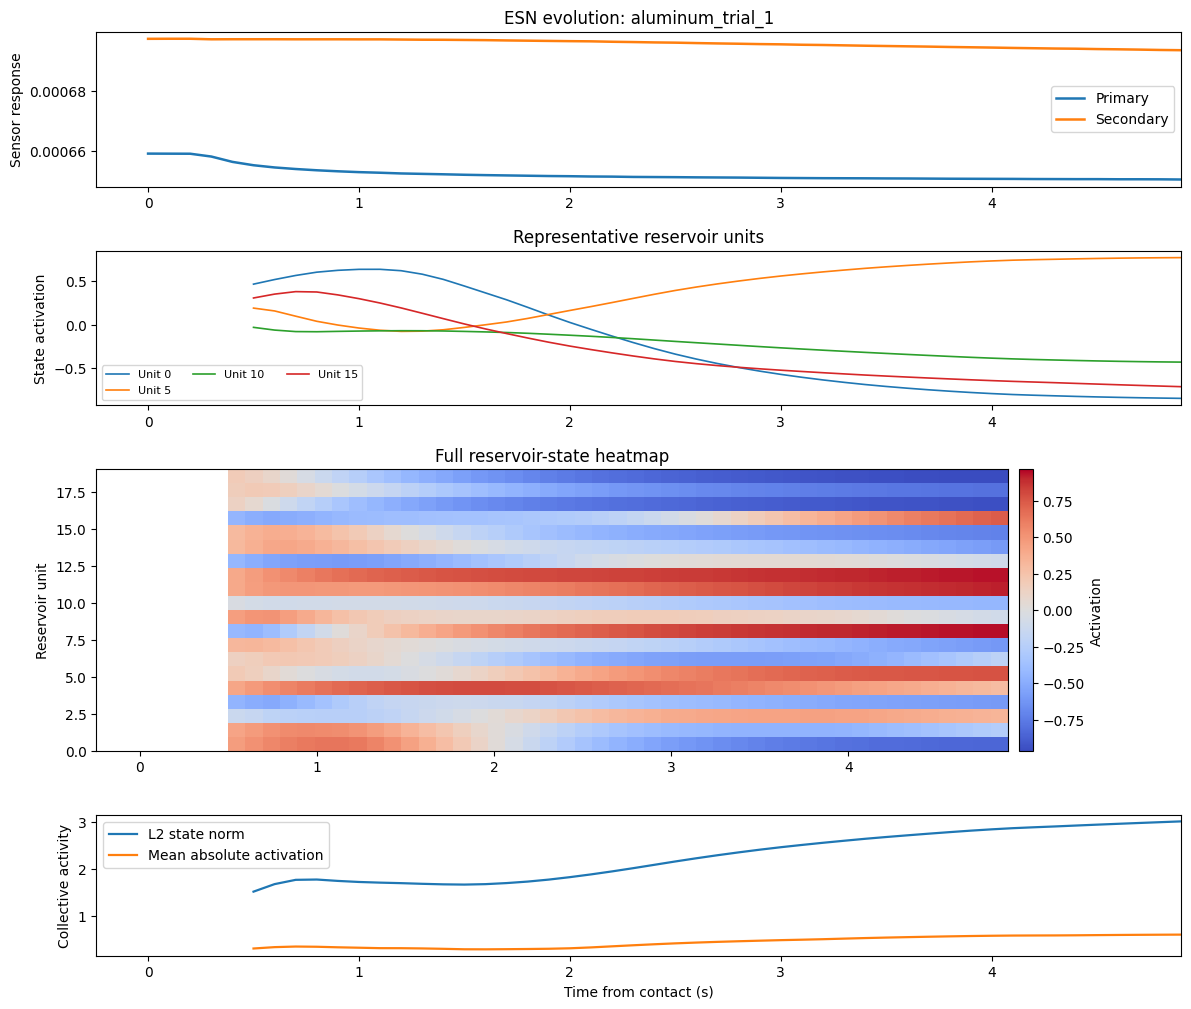

In [84]:
def plot_esn_dynamics(trial_id=SELECTED_TRIAL_ID, units_to_plot=(0, 5, 10, 15, 20, 25)):
    trial, time, scaled_inputs, states = compute_visualization_states(trial_id)

    fig = plt.figure(figsize=(14, 12))
    grid = fig.add_gridspec(4, 1, height_ratios=[1.1, 1.1, 2.0, 1.0], hspace=0.35)

    # Raw sensor response
    ax_inputs = fig.add_subplot(grid[0])
    ax_inputs.plot(
        trial["time_from_contact"], trial["Primary"],
        label="Primary", linewidth=1.8,
    )
    ax_inputs.plot(
        trial["time_from_contact"], trial["Secondary"],
        label="Secondary", linewidth=1.8,
    )
    ax_inputs.set(ylabel="Sensor response", title=f"ESN evolution: {trial_id}")
    ax_inputs.legend(loc="best")

    # Representative reservoir units
    ax_units = fig.add_subplot(grid[1], sharex=ax_inputs)
    valid_units = [unit for unit in units_to_plot if unit < states.shape[1]]
    for unit in valid_units:
        ax_units.plot(time, states[:, unit], label=f"Unit {unit}", linewidth=1.2)
    ax_units.set(ylabel="State activation", title="Representative reservoir units")
    ax_units.legend(ncol=3, fontsize=8)

    # Full state heatmap
    ax_heatmap = fig.add_subplot(grid[2], sharex=ax_inputs)
    limit = np.max(np.abs(states))
    image = ax_heatmap.imshow(
        states.T,
        aspect="auto",
        origin="lower",
        extent=[time.min(), time.max(), 0, states.shape[1] - 1],
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit,
        interpolation="nearest",
    )
    ax_heatmap.set(ylabel="Reservoir unit", title="Full reservoir-state heatmap")
    fig.colorbar(image, ax=ax_heatmap, label="Activation", pad=0.01)

    # Collective reservoir activity
    ax_norm = fig.add_subplot(grid[3], sharex=ax_inputs)
    state_norm = np.linalg.norm(states, axis=1)
    mean_abs_state = np.mean(np.abs(states), axis=1)
    ax_norm.plot(time, state_norm, label="L2 state norm", linewidth=1.6)
    ax_norm.plot(time, mean_abs_state, label="Mean absolute activation", linewidth=1.6)
    ax_norm.set(xlabel="Time from contact (s)", ylabel="Collective activity")
    ax_norm.legend(loc="best")

    plt.show()


plot_esn_dynamics()


## How to interpret the dynamics

- Each heatmap row is one reservoir unit and each column is a post-contact timestep.
- Alternating red and blue patterns show nonlinear units responding with different signs.
- Persistent bands indicate memory of earlier sensor behavior.
- Rapid changes shortly after contact show the reservoir encoding the transient response.
- The state norm summarizes the strength of collective reservoir activation.
- These states are not predictions by themselves; their trajectory summaries become the ESN regression features.


# 7. Leakage-safe regression and metrics


In [85]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    target_range = np.ptp(y_true)
    return {
        "n": len(y_true),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse,
        "nrmse_range": rmse / target_range if target_range > 0 else np.nan,
        "r2": r2_score(y_true, y_pred) if len(y_true) > 1 and target_range > 0 else np.nan,
        "median_ape_pct": np.median(np.abs((y_true - y_pred) / y_true)) * 100,
    }


def make_regressor(alpha, n_components=None):
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
    if n_components is not None:
        steps.append(("pca", PCA(n_components=n_components, random_state=RANDOM_STATE)))
    steps.append(("ridge", Ridge(alpha=alpha)))
    base = Pipeline(steps)
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


def select_alpha(X, y, samples, candidate_alphas=RIDGE_ALPHAS, n_components=None):
    # Inner selection is grouped by material even for held-out-repetition evaluation.
    unique_samples = np.unique(samples)
    n_splits = min(5, len(unique_samples))
    splitter = GroupKFold(n_splits=n_splits)
    rows = []
    for alpha in candidate_alphas:
        errors = []
        for train_idx, valid_idx in splitter.split(X, groups=samples):
            model = make_regressor(alpha, n_components=n_components)
            model.fit(X.iloc[train_idx], y.iloc[train_idx])
            pred = model.predict(X.iloc[valid_idx])
            pred = np.clip(pred, y.iloc[train_idx].min(), y.iloc[train_idx].max())
            errors.append(mean_absolute_error(y.iloc[valid_idx], pred))
        rows.append((alpha, float(np.mean(errors))))
    return min(rows, key=lambda item: item[1])[0], pd.DataFrame(rows, columns=["alpha", "inner_mae"])


# 8. Evaluation engine


In [86]:
def outer_splits(table, protocol):
    if protocol == "held_out_repetition":
        # Trial numbers 1–6 are kept intact across every material.
        splitter = GroupKFold(n_splits=table["Trial"].nunique())
        return splitter.split(table, groups=table["Trial"])
    if protocol == "held_out_material":
        splitter = LeaveOneGroupOut()
        return splitter.split(table, groups=table["Sample"])
    raise ValueError("Unknown protocol.")


def build_esn_feature_table(train_ids, all_ids):
    # Fit input scaling only on outer-training trials.
    scaler = StandardScaler().fit(np.vstack([
        raw_esn_input(aligned_trials[trial_id]) for trial_id in train_ids
    ]))
    reservoir = ManualReservoir(
        res_size=ESN_RES_SIZE,
        leak_rate=ESN_LEAK_RATE,
        input_magnitude=ESN_INPUT_MAGNITUDE,
        spectral_radius=ESN_SPECTRAL_RADIUS,
        washout=ESN_WASHOUT,
        random_state=RANDOM_STATE,
    )
    rows = []
    for trial_id in all_ids:
        trial = aligned_trials[trial_id]
        sequence = scaler.transform(raw_esn_input(trial))
        features = summarize_states(reservoir.run(sequence))
        features.update({
            "trial_id": trial_id,
            "Sample": trial["Sample"].iloc[0],
            "Trial": int(trial["Trial"].iloc[0]),
            "k": float(trial["k"].iloc[0]),
            "eff": float(trial["eff"].iloc[0]),
        })
        rows.append(features)
    return pd.DataFrame(rows)


def evaluate_feature_family(feature_family, target, protocol):
    metadata = THERMAL_FEATURES[["trial_id", "Sample", "Trial", "k", "eff"]].copy()
    fold_rows, prediction_rows = [], []

    for fold, (train_idx, test_idx) in enumerate(outer_splits(metadata, protocol), start=1):
        train_meta = metadata.iloc[train_idx]
        test_meta = metadata.iloc[test_idx]
        train_ids = train_meta["trial_id"].tolist()
        test_ids = test_meta["trial_id"].tolist()

        if set(train_ids) & set(test_ids):
            raise RuntimeError("Trial leakage detected.")
        if protocol == "held_out_material":
            if set(train_meta["Sample"]) & set(test_meta["Sample"]):
                raise RuntimeError("Material leakage detected.")

        if feature_family == "thermal":
            fold_features = THERMAL_FEATURES
            n_components = None
        elif feature_family == "esn":
            fold_features = build_esn_feature_table(
                train_ids=train_ids,
                all_ids=train_ids + test_ids,
            )
            # Limit ESN dimensionality inside the model.
            n_components = min(10, len(train_ids) - 1)
        else:
            raise ValueError("feature_family must be thermal or esn")

        indexed = fold_features.set_index("trial_id")
        excluded = {"Sample", "Trial", "k", "eff"}
        feature_cols = [
            c for c in fold_features.select_dtypes(include=np.number).columns
            if c not in excluded
        ]
        X_train = indexed.loc[train_ids, feature_cols].reset_index(drop=True)
        X_test = indexed.loc[test_ids, feature_cols].reset_index(drop=True)
        y_train = indexed.loc[train_ids, target].reset_index(drop=True)
        y_test = indexed.loc[test_ids, target].reset_index(drop=True)
        samples_train = indexed.loc[train_ids, "Sample"].to_numpy()

        alpha, _ = select_alpha(
            X_train, y_train, samples_train, n_components=n_components
        )
        model = make_regressor(alpha, n_components=n_components)
        model.fit(X_train, y_train)
        raw_pred = model.predict(X_test)
        pred = np.clip(raw_pred, y_train.min(), y_train.max())

        fold_rows.append({
            "fold": fold,
            "feature_family": feature_family,
            "target": target,
            "protocol": protocol,
            "selected_alpha": alpha,
            "test_materials": ", ".join(sorted(set(test_meta["Sample"]))),
            **regression_metrics(y_test, pred),
        })
        prediction_rows.append(pd.DataFrame({
            "trial_id": test_ids,
            "Sample": test_meta["Sample"].to_numpy(),
            "Trial": test_meta["Trial"].to_numpy(),
            "fold": fold,
            "y_true": y_test,
            "y_pred": pred,
        }))

    fold_metrics = pd.DataFrame(fold_rows)
    predictions = pd.concat(prediction_rows, ignore_index=True)
    overall = pd.DataFrame([{
        "feature_family": feature_family,
        "target": target,
        "protocol": protocol,
        **regression_metrics(predictions["y_true"], predictions["y_pred"]),
    }])
    return fold_metrics, overall, predictions


# 9. Fixed Temperature: held-out repetitions

This protocol tests a new experimental repetition while other trials of the same
materials remain in training. It is the appropriate primary measure of repeatability.


In [87]:
repetition_results = []
repetition_predictions = {}

for family in ("thermal", "esn"):
    for target in ("k", "eff"):
        folds, overall, predictions = evaluate_feature_family(
            family, target, "held_out_repetition"
        )
        repetition_results.append(overall)
        repetition_predictions[(family, target)] = predictions

REPETITION_RESULTS = pd.concat(repetition_results, ignore_index=True)
display(REPETITION_RESULTS)


,feature_family,target,protocol,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,thermal,k,held_out_repetition,84,39.817677,87.078290,0.217171,0.407289,77.333333
1,thermal,eff,held_out_repetition,84,4710.361943,8667.653717,0.233264,0.401959,55.311132
2,esn,k,held_out_repetition,84,38.931609,82.092080,0.204736,0.473225,80.000000
3,esn,eff,held_out_repetition,84,3262.815313,6672.506793,0.179571,0.645590,44.686969


# 10. Fixed Temperature: held-out materials

This protocol excludes every trial of one material. It estimates whether the model can
predict properties for a material absent from training. This is the more difficult and
more important test for unseen-material claims.


In [88]:
material_results = []
material_predictions = {}

for family in ("thermal", "esn"):
    for target in ("k", "eff"):
        folds, overall, predictions = evaluate_feature_family(
            family, target, "held_out_material"
        )
        material_results.append(overall)
        material_predictions[(family, target)] = predictions

MATERIAL_RESULTS = pd.concat(material_results, ignore_index=True)
display(MATERIAL_RESULTS)


,feature_family,target,protocol,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,thermal,k,held_out_material,84,55.115840,108.487094,0.270564,0.080018,80.000000
1,thermal,eff,held_out_material,84,5470.202398,9833.415892,0.264637,0.230273,67.394573
2,esn,k,held_out_material,84,55.807507,114.321989,0.285116,-0.021604,116.704140
3,esn,eff,held_out_material,84,3668.450580,7362.935533,0.198152,0.568451,65.654621


# 11. Compare actual and predicted values


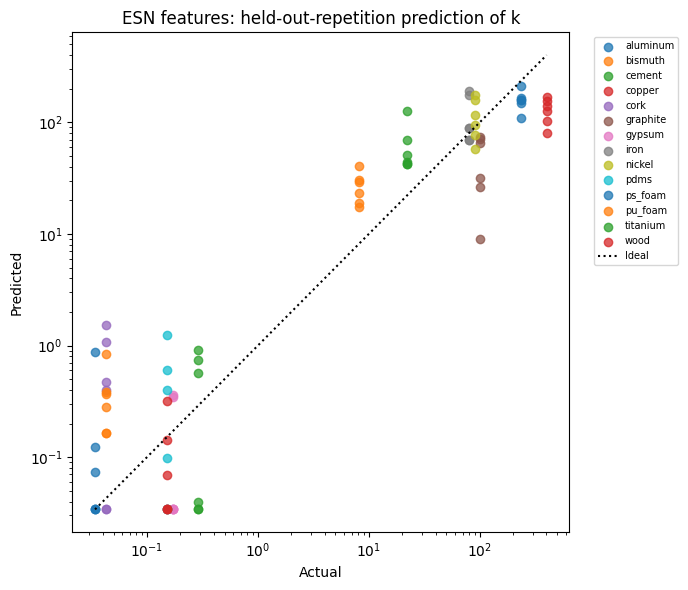

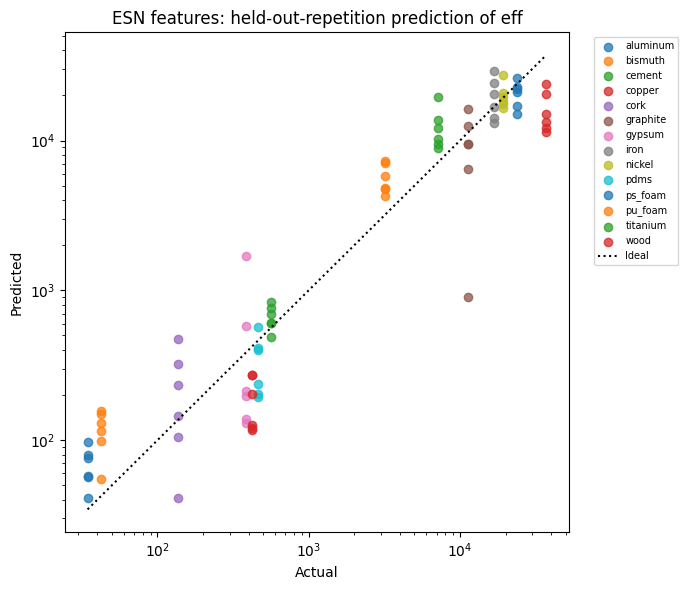

In [89]:
def plot_actual_predicted(predictions, title):
    positive = (predictions["y_true"] > 0) & (predictions["y_pred"] > 0)
    shown = predictions[positive]
    fig, ax = plt.subplots(figsize=(7, 6))
    for material, part in shown.groupby("Sample"):
        ax.scatter(part["y_true"], part["y_pred"], label=material, alpha=0.75)
    low = min(shown["y_true"].min(), shown["y_pred"].min())
    high = max(shown["y_true"].max(), shown["y_pred"].max())
    ax.plot([low, high], [low, high], color="black", linestyle=":", label="Ideal")
    ax.set(xscale="log", yscale="log", xlabel="Actual", ylabel="Predicted", title=title)
    ax.legend(fontsize=7, bbox_to_anchor=(1.04, 1), loc="upper left")
    fig.tight_layout()
    plt.show()

plot_actual_predicted(
    repetition_predictions[("esn", "k")],
    "ESN features: held-out-repetition prediction of k",
)
plot_actual_predicted(
    repetition_predictions[("esn", "eff")],
    "ESN features: held-out-repetition prediction of eff",
)


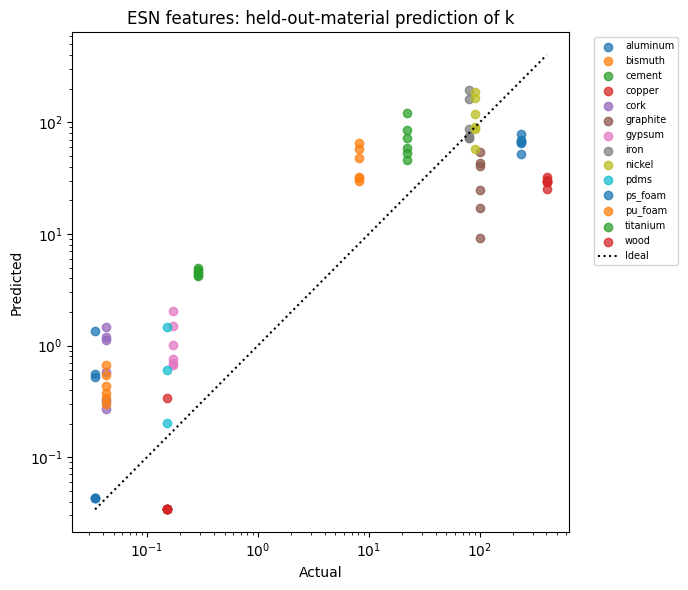

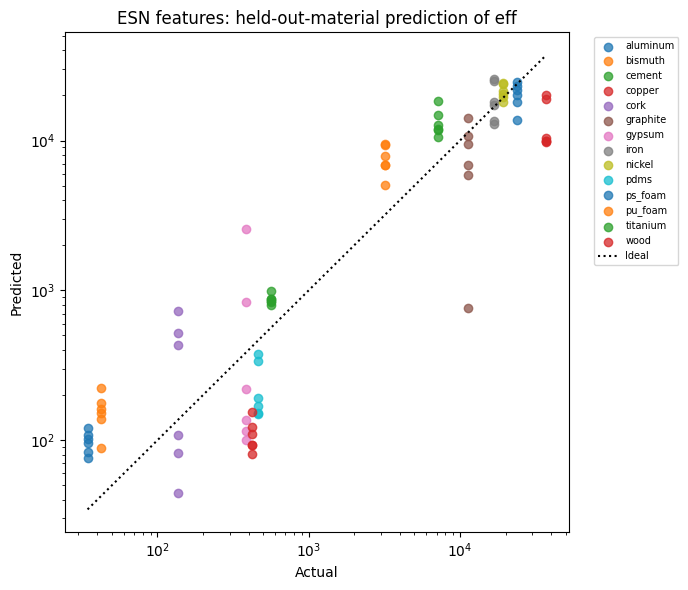

In [90]:
plot_actual_predicted(
    material_predictions[("esn", "k")],
    "ESN features: held-out-material prediction of k",
)
plot_actual_predicted(
    material_predictions[("esn", "eff")],
    "ESN features: held-out-material prediction of eff",
)


# 12. Material-grouped ESN hyperparameter grid search

This optional process selects an ESN configuration using out-of-fold predictions
from material-grouped cross-validation. It can either:

- maximize `r2`, or
- minimize `nrmse_range`.

The search jointly considers reservoir and Ridge-readout parameters. Scaling, PCA,
and model fitting are repeated inside every validation fold.

**Important:** a score used to select hyperparameters is a validation score, not a
final independent test score. For a publication-grade final estimate, place this
search inside each outer training fold (nested cross-validation) or evaluate the
selected configuration on a separately reserved set of materials.


In [91]:
def grid_search_esn_hyperparameters(
    target="eff",
    objective="r2",
    parameter_grid=None,
    n_splits=5,
    pca_components=10,
):
    if target not in {"k", "eff"}:
        raise ValueError("target must be 'k' or 'eff'")
    if objective not in {"r2", "nrmse_range"}:
        raise ValueError("objective must be 'r2' or 'nrmse_range'")

    if parameter_grid is None:
        # Deliberately compact defaults. Expand only when computation and
        # independent material count justify a larger search.
        parameter_grid = {
            "res_size": [20, 30, 50],
            "leak_rate": [0.1, 0.5, 0.9],
            "input_magnitude": [0.5, 1.0, 1.5],
            "spectral_radius": [0.7, 1.0, 1.3],
            "washout": [0, 5, 10],
            "ridge_alpha": [1.0, 10.0, 100.0, 1000.0],
        }

    required_keys = {
        "res_size", "leak_rate", "input_magnitude",
        "spectral_radius", "washout", "ridge_alpha",
    }
    missing = required_keys - set(parameter_grid)
    if missing:
        raise KeyError(f"parameter_grid is missing: {sorted(missing)}")

    metadata = THERMAL_FEATURES[
        ["trial_id", "Sample", "Trial", "k", "eff"]
    ].reset_index(drop=True)
    unique_materials = metadata["Sample"].nunique()
    if n_splits < 2 or n_splits > unique_materials:
        raise ValueError(
            f"n_splits must be between 2 and {unique_materials}"
        )

    splitter = GroupKFold(n_splits=n_splits)
    split_indices = list(
        splitter.split(metadata, groups=metadata["Sample"])
    )

    keys = [
        "res_size", "leak_rate", "input_magnitude",
        "spectral_radius", "washout", "ridge_alpha",
    ]
    combinations = list(product(*(parameter_grid[key] for key in keys)))
    result_rows = []

    for combination_number, values in enumerate(combinations, start=1):
        params = dict(zip(keys, values))
        oof_rows = []

        for fold, (train_idx, valid_idx) in enumerate(split_indices, start=1):
            train_meta = metadata.iloc[train_idx]
            valid_meta = metadata.iloc[valid_idx]
            train_ids = train_meta["trial_id"].tolist()
            valid_ids = valid_meta["trial_id"].tolist()

            if set(train_meta["Sample"]) & set(valid_meta["Sample"]):
                raise RuntimeError("Material leakage detected during grid search.")

            # Fold-local input scaling.
            input_scaler = StandardScaler().fit(np.vstack([
                raw_esn_input(aligned_trials[trial_id])
                for trial_id in train_ids
            ]))
            reservoir = ManualReservoir(
                res_size=params["res_size"],
                leak_rate=params["leak_rate"],
                input_magnitude=params["input_magnitude"],
                spectral_radius=params["spectral_radius"],
                washout=params["washout"],
                random_state=RANDOM_STATE,
            )

            feature_rows = []
            for trial_id in train_ids + valid_ids:
                trial = aligned_trials[trial_id]
                sequence = input_scaler.transform(raw_esn_input(trial))
                features = summarize_states(reservoir.run(sequence))
                features.update({
                    "trial_id": trial_id,
                    target: float(trial[target].iloc[0]),
                })
                feature_rows.append(features)

            features = pd.DataFrame(feature_rows).set_index("trial_id")
            feature_cols = [c for c in features.columns if c.startswith("esn_")]
            X_train = features.loc[train_ids, feature_cols].reset_index(drop=True)
            X_valid = features.loc[valid_ids, feature_cols].reset_index(drop=True)
            y_train = features.loc[train_ids, target].reset_index(drop=True)
            y_valid = features.loc[valid_ids, target].reset_index(drop=True)

            components = min(
                int(pca_components),
                X_train.shape[1],
                len(X_train) - 1,
            )
            model = make_regressor(
                alpha=params["ridge_alpha"],
                n_components=components,
            )
            model.fit(X_train, y_train)
            raw_prediction = model.predict(X_valid)
            prediction = np.clip(
                raw_prediction,
                y_train.min(),
                y_train.max(),
            )
            oof_rows.append(pd.DataFrame({
                "y_true": y_valid,
                "y_pred": prediction,
                "fold": fold,
            }))

        oof = pd.concat(oof_rows, ignore_index=True)
        metrics = regression_metrics(oof["y_true"], oof["y_pred"])
        result_rows.append({
            **params,
            "target": target,
            "objective": objective,
            **metrics,
        })

    results = pd.DataFrame(result_rows)
    ascending = objective == "nrmse_range"
    results = (
        results.sort_values(
            objective,
            ascending=ascending,
            na_position="last",
        )
        .reset_index(drop=True)
    )
    best = results.iloc[0].to_dict()
    return results, best


In [92]:
# Choose the target and optimization criterion here.
GRID_TARGET = "eff"             # "k" or "eff"
GRID_OBJECTIVE = "r2"           # "r2" or "nrmse_range"

# This compact grid contains 2×2×2×2×2×3 = 96 combinations.
GRID_RESULTS, BEST_ESN_PARAMETERS = grid_search_esn_hyperparameters(
    target=GRID_TARGET,
    objective=GRID_OBJECTIVE,
    n_splits=5,
    pca_components=10,
)

print("Optimization target:", GRID_TARGET)
print("Optimization objective:", GRID_OBJECTIVE)
print("\nBest combination:")
display(pd.Series(BEST_ESN_PARAMETERS))
print("\nTop 10 combinations:")
display(GRID_RESULTS.head(10))


Optimization target: eff
Optimization objective: r2

Best combination:


res_size                    20
leak_rate                  0.1
input_magnitude            1.5
spectral_radius            0.7
washout                      5
ridge_alpha                1.0
target                     eff
objective                   r2
n                           84
mae                3640.295295
rmse               7154.685392
nrmse_range           0.192547
r2                    0.592517
median_ape_pct        63.14102
dtype: object


Top 10 combinations:


,res_size,leak_rate,input_magnitude,spectral_radius,washout,ridge_alpha,target,objective,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,20,0.1,1.5,0.7,5,1.0,eff,r2,84,3640.295295,7154.685392,0.192547,0.592517,63.141020
1,20,0.5,0.5,0.7,0,1.0,eff,r2,84,3836.058242,7232.853629,0.194651,0.583565,54.848155
2,20,0.9,0.5,1.0,0,1.0,eff,r2,84,3986.529065,7238.778454,0.194810,0.582882,51.581936
3,20,0.9,0.5,0.7,0,1.0,eff,r2,84,3945.990848,7476.423728,0.201206,0.555045,55.236133
4,30,0.9,1.5,1.0,0,1.0,eff,r2,84,4284.325353,7486.855366,0.201486,0.553803,53.340541
5,30,0.5,1.0,1.0,0,1.0,eff,r2,84,4129.723376,7542.404561,0.202981,0.547157,51.097091
6,20,0.1,1.5,0.7,0,1.0,eff,r2,84,3848.529804,7627.263499,0.205265,0.536910,46.825741
7,30,0.5,1.0,1.0,0,10.0,eff,r2,84,4124.760677,7702.381986,0.207287,0.527743,55.935357
8,30,0.9,1.5,0.7,0,1.0,eff,r2,84,4459.880067,7720.482027,0.207774,0.525521,60.801842
9,20,0.9,0.5,1.0,0,10.0,eff,r2,84,4116.476728,7724.439717,0.207880,0.525035,58.472513


## Searching by low NRMSE instead

Change:

```python
GRID_OBJECTIVE = "nrmse_range"
```

and rerun the grid-search cell. The function automatically sorts NRMSE in ascending
order and R² in descending order.

To search a custom grid:

```python
custom_grid = {
    "res_size": [20, 30, 50],
    "leak_rate": [0.1, 0.5, 0.9],
    "input_magnitude": [0.5, 1.0, 1.5],
    "spectral_radius": [0.7, 1.0, 1.3],
    "washout": [0, 5, 10],
    "ridge_alpha": [1.0, 10.0, 100.0, 1000.0],
}

results, best = grid_search_esn_hyperparameters(
    target="k",
    objective="nrmse_range",
    parameter_grid=custom_grid,
)
```

Avoid interpreting tiny differences between configurations as meaningful: there are
only 14 independent materials.


# 13. Interpretation rules

- `k` is constant for repeated trials of each material. `eff` may vary by trial because
  measured density can vary, but the effective number of independent material types is still 14.
- High held-out-repetition performance shows repeatability for represented materials.
- Only held-out-material performance supports a claim about unseen materials.
- `eff = sqrt(k × rho × cp)` is derived from literature properties; it is not independently measured.
- `rho`, `cp`, `k`, and `eff` are not used as predictors.
- ESN states are reduced with PCA fitted inside each training fold.
- Ridge regularization is selected using material-grouped inner validation.
- Hyperparameter exploration beyond the fixed candidate set requires nested validation.
- Poor held-out-material results are a data/generalization finding, not automatically a coding error.
- Add more independent materials—especially outside the metal class—to strengthen generalization claims.
